# Fourier Equivalence Study: Three Ways to Build the Same Beam Family

This notebook compares three constructions:

1. `FourierTransform(f)` applied to a coherent Gaussian bundle filling a circular aperture.
2. Explicit free-space by `f`, then `Lens(f)`, then free-space by `f`.
3. A direct point-source Gaussian bundle matched to the Fourier result angular support.

The notebook verifies equivalence by comparing:

- Method 1 vs Method 2 fields/intensities at the Fourier plane and after extra propagation.
- Method 3 vs Fourier methods in angle support and propagated beam extent.

In [123]:
import os

os.environ['JAX_ENABLE_X64'] = '1'

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from temgym_core.source import circular_input_wave
from temgym_core.gaussian import make_gaussian
from temgym_core.components import Detector, Plane, Lens, FourierTransform
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.run import run_to_end_vmapped
from temgym_core.utils import fibonacci_spiral

jax.config.update('jax_enable_x64', True)

%matplotlib widget

In [124]:
# Global settings
voltage = 10000
waist = 1.0e-7
n_target = 2500000

# Optical geometry
f = 0.10
z_in = 0.0
z_fourier = z_in + 2.0 * f
z_compare = z_fourier + f

# Input circular aperture to be Fourier-transformed
input_aperture_radius = 100e-6

# Detector settings
shape = (128, 128)
half_width_fourier = 140e-6
half_width_compare = 300e-6

print(f'Target rays: {n_target}')
print(f'Input aperture radius: {input_aperture_radius * 1e6:.1f} um')
print(f'Focal length: {f:.3f} m')
print(f'Fourier plane z: {z_fourier:.3f} m')
print(f'Comparison plane z: {z_compare:.3f} m')

Target rays: 2500000
Input aperture radius: 100.0 um
Focal length: 0.100 m
Fourier plane z: 0.200 m
Comparison plane z: 0.300 m


In [129]:
import numpy as np

from temgym_core.components import (
    Detector,
    Lens,
    Plane,
    SigmoidAperture,
    FourierTransform,
)
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.gaussian import GaussianBeam, make_gaussian
from temgym_core.run import run_to_end_vmapped
from temgym_core.source import circular_input_wave, fibonacci_spiral


def overlap_from_target_count(target_n, aperture_radius, waist):
    area = np.pi * float(aperture_radius) ** 2
    n = max(int(target_n), 1)
    if area <= 0.0:
        return 2.0
    overlap = np.sqrt(n * float(waist) ** 2 / area)
    return float(np.clip(overlap, 0.02, 16.0))


def make_aperture_input_bundle(target_n, aperture_radius, waist, voltage, z0=0.0):
    overlap = overlap_from_target_count(target_n, aperture_radius, waist)
    return circular_input_wave(
        aperture_radius=float(aperture_radius),
        waist=float(waist),
        voltage=float(voltage),
        z0=float(z0),
        overlap_factor=overlap,
        sampling='fibonacci',
        phase=0.0,
        wavelength_unit='m',
    )


def make_point_gaussian_bundle(n, theta_max, waist, voltage, z0=0.0):
    dx, dy = fibonacci_spiral(int(n), float(theta_max))
    dx = np.asarray(dx, dtype=float)
    dy = np.asarray(dy, dtype=float)
    zeros = np.zeros((int(n),), dtype=float)
    infs = np.full((int(n),), np.inf, dtype=float)
    amp = np.full((int(n),), 1.0 / max(int(n), 1), dtype=float)

    return make_gaussian(
        x=zeros,
        y=zeros,
        dx=dx,
        dy=dy,
        z=np.full((int(n),), float(z0), dtype=float),
        voltage=np.full((int(n),), float(voltage), dtype=float),
        waist_x=np.full((int(n),), float(waist), dtype=float),
        waist_y=np.full((int(n),), float(waist), dtype=float),
        amp=amp,
        phase=zeros,
        rcurv_x=infs,
        rcurv_y=infs,
        wavelength_unit='m',
    )


def make_point_source_from_math(n, theta_max, waist, voltage, z0=0.0):
    """Point source at (0,0) with field amplitude 1 at the centre.

    No `f` parameter — the Gaussian state is specified directly at z0.

    Parameters
    ----------
    n : int
        Number of rays.
    theta_max : float
        Maximum half-angle [rad].
    waist : float
        Gaussian half-width of each component **at z0** [m].
        To match the focal spot of a 2f system with input waist w_in and
        focal length f, pass  waist = f * lambda / (pi * w_in).
    voltage : float
        Electron energy [V].
    z0 : float
        z-position of the point source [m].

    Notes
    -----
    Each of the N rays carries amplitude 1/N (real), so the total field
    at the origin  E(0,0) = sum_j a_j = 1.  pathlength is zero (source
    placed directly at z0).  Q_inv = i*lambda/(pi*waist^2)*I_2, i.e. a
    flat-wavefront Gaussian sitting exactly at its own waist — no prior
    propagation history assumed.
    """
    n = int(n)
    dx, dy = fibonacci_spiral(n, float(theta_max))
    dx = np.asarray(dx, dtype=float)
    dy = np.asarray(dy, dtype=float)
    zeros = np.zeros(n, dtype=float)

    return make_gaussian(
        x=zeros,
        y=zeros,
        dx=dx,
        dy=dy,
        z=np.full(n, float(z0), dtype=float),
        voltage=np.full(n, float(voltage), dtype=float),
        waist_x=np.full(n, float(waist), dtype=float),
        waist_y=np.full(n, float(waist), dtype=float),
        amp=np.full(n, 1.0 / max(n, 1), dtype=float),
        phase=zeros,
        rcurv_x=np.full(n, np.inf, dtype=float),
        rcurv_y=np.full(n, np.inf, dtype=float),
        wavelength_unit='m',
    )


def make_square_detector(z, half_width, shape=(256, 256)):
    pixel = (2.0 * float(half_width)) / float(shape[0])
    return Detector(z=float(z), pixel_size=(pixel, pixel), shape=shape)


def field_and_intensity(beam, detector):
    field = np.asarray(evaluate_gaussians_gpu_kernel_wrapper(beam, detector))
    intensity = np.abs(field) ** 2
    return field, intensity


def integrated_power(intensity, detector):
    pixel_area = float(detector.pixel_size[0]) * float(detector.pixel_size[1])
    return float(np.sum(np.asarray(intensity, dtype=float)) * pixel_area)


def rel_l2(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    num = np.linalg.norm(a - b)
    den = max(np.linalg.norm(a), 1e-30)
    return float(num / den)


def max_angle(beam):
    return float(np.max(np.hypot(np.asarray(beam.dx), np.asarray(beam.dy))))


def rms_radius(beam):
    x = np.asarray(beam.x)
    y = np.asarray(beam.y)
    r = np.hypot(x, y)
    return float(np.sqrt(np.mean(r ** 2)))


In [130]:
# Build common aperture input bundle
beam_ap = make_aperture_input_bundle(
    target_n=n_target,
    aperture_radius=input_aperture_radius,
    waist=waist,
    voltage=voltage,
    z0=z_in,
)
n_realized = int(np.size(np.asarray(beam_ap.x)))

# Method 1: Dedicated FourierTransform component
beam_ft = run_to_end_vmapped(beam_ap, [FourierTransform(f=float(f))])

# Method 2: Explicit free-space f -> lens f -> free-space f
beam_chain = run_to_end_vmapped(
    beam_ap,
    [
        Plane(z=z_in + f),
        Lens(z=z_in + f, focal_length=f),
        Plane(z=z_fourier),
    ],
)

# Method 3: Pure analytical point-source construction (no aperture propagation, no f)
#   theta_max comes from the aperture geometry; waist_at_focus is the Fourier-plane
#   spot size derived from the Gaussian 2f transform: w_out = f*lambda/(pi*w_in).
#   Pass waist_at_focus as the component width so the shape comparison is meaningful.
theta_max_ft = input_aperture_radius / f
lam_val = float(energy2wavelength(voltage))
waist_at_focus = f * lam_val / (np.pi * waist)   # Gaussian Fourier transform relation

beam_point = make_point_source_from_math(
    n=n_realized,
    theta_max=theta_max_ft,
    waist=waist_at_focus,
    voltage=voltage,
    z0=z_fourier,
)

# Detectors at Fourier plane and downstream comparison plane
det_fourier = make_square_detector(z_fourier, half_width_fourier, shape=shape)
det_compare = make_square_detector(z_compare, half_width_compare, shape=shape)

field_ft_fourier, inten_ft_fourier = field_and_intensity(beam_ft, det_fourier)
field_chain_fourier, inten_chain_fourier = field_and_intensity(beam_chain, det_fourier)
field_point_fourier, inten_point_fourier = field_and_intensity(beam_point, det_fourier)

# Propagate all methods to a common downstream comparison plane
beam_ft_cmp = run_to_end_vmapped(beam_ft, [Plane(z=z_compare)])
beam_chain_cmp = run_to_end_vmapped(beam_chain, [Plane(z=z_compare)])
beam_point_cmp = run_to_end_vmapped(beam_point, [Plane(z=z_compare)])

field_ft_cmp, inten_ft_cmp = field_and_intensity(beam_ft_cmp, det_compare)
field_chain_cmp, inten_chain_cmp = field_and_intensity(beam_chain_cmp, det_compare)
field_point_cmp, inten_point_cmp = field_and_intensity(beam_point_cmp, det_compare)

print(f'Realized aperture rays                   : {n_realized}')
print(f'Fourier theta_max from pupil/f [mrad]    : {1e3 * theta_max_ft:.4f}')
print(f'Point source theta_max [mrad]            : {1e3 * max_angle(beam_point):.4f}')
print(f'Waist at focus [um]                      : {1e6 * waist_at_focus:.4f}')
print(f'E(0,0) point source                      : {float(np.sum(np.asarray(beam_point.amplitude).real)):.6f}')


Realized aperture rays                   : 2500000
Fourier theta_max from pupil/f [mrad]    : 1.0000
Point source theta_max [mrad]            : 1.0000
Waist at focus [um]                      : 3.8849
E(0,0) point source                      : 1.000000


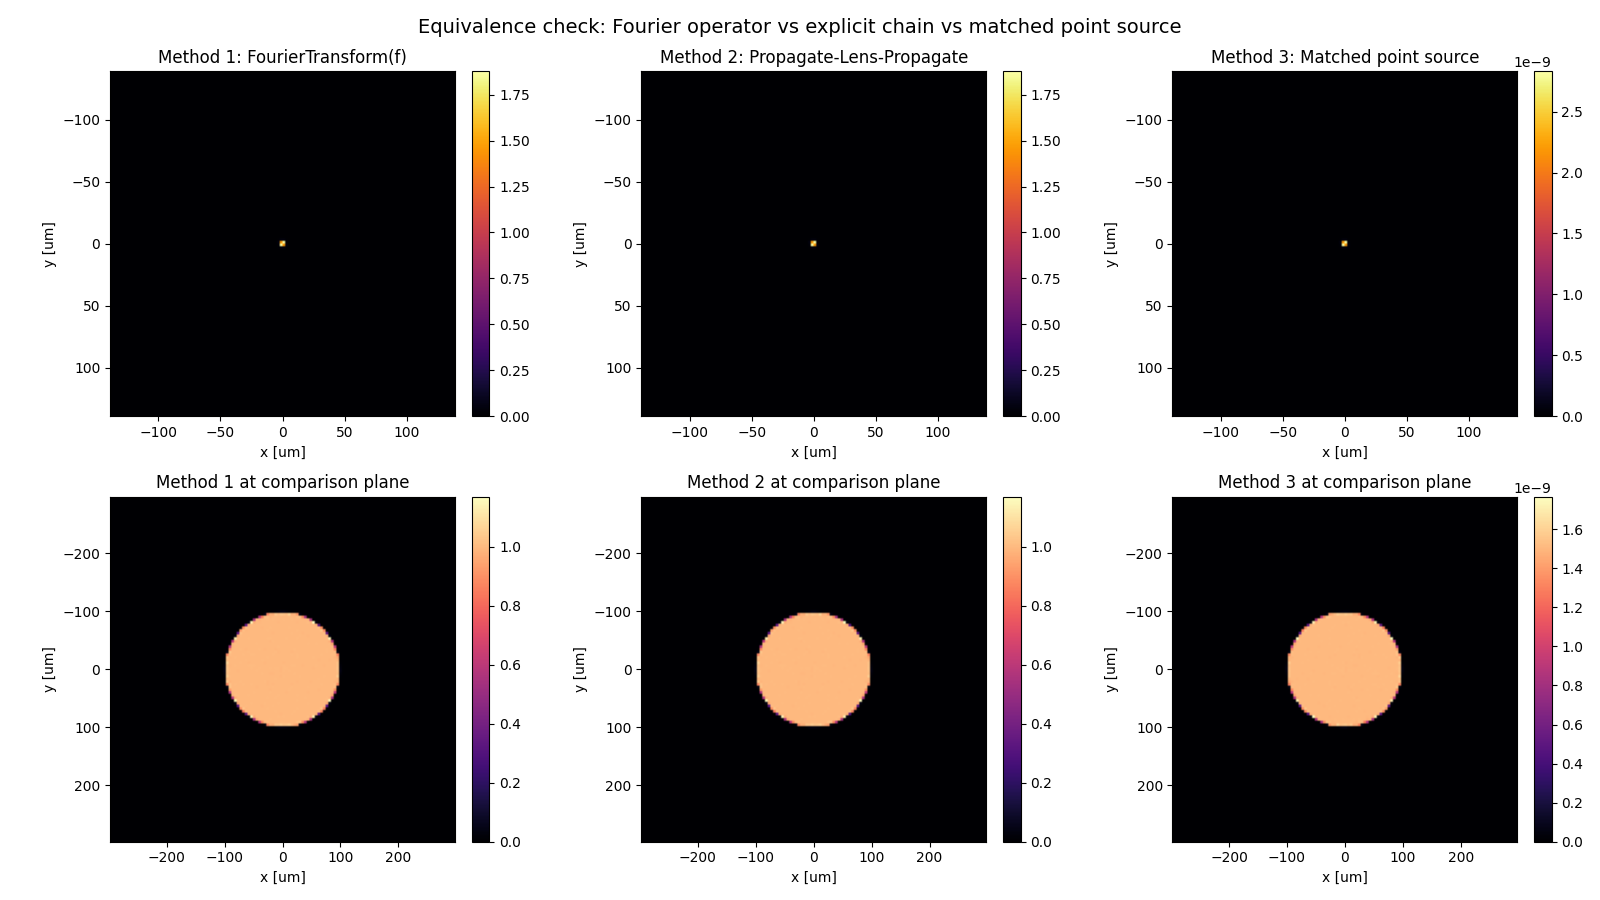

In [127]:
extent_fourier_um = np.asarray(det_fourier.extent) * 1e6
extent_compare_um = np.asarray(det_compare.extent) * 1e6

# Use per-panel normalization for fair visual shape comparison
vmax_ft_fourier = max(float(np.max(inten_ft_fourier)), 1e-30)
vmax_chain_fourier = max(float(np.max(inten_chain_fourier)), 1e-30)
vmax_point_fourier = max(float(np.max(inten_point_fourier)), 1e-30)

vmax_ft_compare = max(float(np.max(inten_ft_cmp)), 1e-30)
vmax_chain_compare = max(float(np.max(inten_chain_cmp)), 1e-30)
vmax_point_compare = max(float(np.max(inten_point_cmp)), 1e-30)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

im00 = axes[0, 0].imshow(inten_ft_fourier, origin='lower', extent=extent_fourier_um, cmap='inferno', vmin=0, vmax=vmax_ft_fourier)
axes[0, 0].set_title('Method 1: FourierTransform(f)')
axes[0, 0].set_xlabel('x [um]')
axes[0, 0].set_ylabel('y [um]')
axes[0, 0].set_aspect('equal')
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(inten_chain_fourier, origin='lower', extent=extent_fourier_um, cmap='inferno', vmin=0, vmax=vmax_chain_fourier)
axes[0, 1].set_title('Method 2: Propagate-Lens-Propagate')
axes[0, 1].set_xlabel('x [um]')
axes[0, 1].set_ylabel('y [um]')
axes[0, 1].set_aspect('equal')
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(inten_point_fourier, origin='lower', extent=extent_fourier_um, cmap='inferno', vmin=0, vmax=vmax_point_fourier)
axes[0, 2].set_title('Method 3: Matched point source')
axes[0, 2].set_xlabel('x [um]')
axes[0, 2].set_ylabel('y [um]')
axes[0, 2].set_aspect('equal')
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

im10 = axes[1, 0].imshow(inten_ft_cmp, origin='lower', extent=extent_compare_um, cmap='magma', vmin=0, vmax=vmax_ft_compare)
axes[1, 0].set_title('Method 1 at comparison plane')
axes[1, 0].set_xlabel('x [um]')
axes[1, 0].set_ylabel('y [um]')
axes[1, 0].set_aspect('equal')
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(inten_chain_cmp, origin='lower', extent=extent_compare_um, cmap='magma', vmin=0, vmax=vmax_chain_compare)
axes[1, 1].set_title('Method 2 at comparison plane')
axes[1, 1].set_xlabel('x [um]')
axes[1, 1].set_ylabel('y [um]')
axes[1, 1].set_aspect('equal')
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(inten_point_cmp, origin='lower', extent=extent_compare_um, cmap='magma', vmin=0, vmax=vmax_point_compare)
axes[1, 2].set_title('Method 3 at comparison plane')
axes[1, 2].set_xlabel('x [um]')
axes[1, 2].set_ylabel('y [um]')
axes[1, 2].set_aspect('equal')
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle('Equivalence check: Fourier operator vs explicit chain vs matched point source', fontsize=14)
plt.tight_layout()
plt.show()

In [132]:
# Method 1 vs Method 2 should match closely in complex field and intensity
err_field_fourier = rel_l2(field_ft_fourier, field_chain_fourier)
err_inten_fourier = rel_l2(inten_ft_fourier, inten_chain_fourier)
err_field_compare = rel_l2(field_ft_cmp, field_chain_cmp)
err_inten_compare = rel_l2(inten_ft_cmp, inten_chain_cmp)

# For method 3, compare normalised intensity shape and beam geometry support.
# Power ratio is informational only: Method 3 has amplitude=1/N normalisation
# (E(0,0)=1), which differs from the aperture-power-equivalent normalisation
# used by Methods 1 and 2.
norm_ft_cmp = inten_ft_cmp / max(float(np.max(inten_ft_cmp)), 1e-30)
norm_point_cmp = inten_point_cmp / max(float(np.max(inten_point_cmp)), 1e-30)
err_shape_point_compare = rel_l2(norm_ft_cmp, norm_point_cmp)

theta_ft = max_angle(beam_ft)
theta_chain = max_angle(beam_chain)
theta_point = max_angle(beam_point)

theta_err_chain = abs(theta_chain - theta_ft) / max(theta_ft, 1e-30)
theta_err_point = abs(theta_point - theta_ft) / max(theta_ft, 1e-30)

rms_ft_cmp = rms_radius(beam_ft_cmp)
rms_chain_cmp = rms_radius(beam_chain_cmp)
rms_point_cmp = rms_radius(beam_point_cmp)

rms_err_chain = abs(rms_chain_cmp - rms_ft_cmp) / max(rms_ft_cmp, 1e-30)
rms_err_point = abs(rms_point_cmp - rms_ft_cmp) / max(rms_ft_cmp, 1e-30)

p_ft_fourier = integrated_power(inten_ft_fourier, det_fourier)
p_point_fourier = integrated_power(inten_point_fourier, det_fourier)
p_ft_compare = integrated_power(inten_ft_cmp, det_compare)
p_point_compare = integrated_power(inten_point_cmp, det_compare)

print('Method 1 vs Method 2 (operator vs explicit chain)')
print(f'  Relative field error at Fourier plane : {err_field_fourier:.3e}')
print(f'  Relative intensity error at Fourier plane : {err_inten_fourier:.3e}')
print(f'  Relative field error at comparison plane : {err_field_compare:.3e}')
print(f'  Relative intensity error at comparison plane : {err_inten_compare:.3e}')

print('')
print('Method 3 vs Fourier support (matched point source, amplitude=1/N normalisation)')
print(f'  Theta_max method1 [mrad] : {1e3 * theta_ft:.6f}')
print(f'  Theta_max method2 [mrad] : {1e3 * theta_chain:.6f}')
print(f'  Theta_max method3 [mrad] : {1e3 * theta_point:.6f}')
print(f'  Theta relative error method2 vs method1 : {theta_err_chain:.3e}')
print(f'  Theta relative error method3 vs method1 : {theta_err_point:.3e}')
print(f'  RMS radius at compare plane method1 [um] : {1e6 * rms_ft_cmp:.6f}')
print(f'  RMS radius at compare plane method2 [um] : {1e6 * rms_chain_cmp:.6f}')
print(f'  RMS radius at compare plane method3 [um] : {1e6 * rms_point_cmp:.6f}')
print(f'  RMS relative error method2 vs method1 : {rms_err_chain:.3e}')
print(f'  RMS relative error method3 vs method1 : {rms_err_point:.3e}')
print(f'  Normalised intensity-shape error (method3 vs method1) at compare plane : {err_shape_point_compare:.3e}')
print(f'  Power ratio at Fourier plane (method3/method1) [info only] : {p_point_fourier / max(p_ft_fourier, 1e-30):.3e}')
print(f'  Power ratio at compare plane (method3/method1) [info only] : {p_point_compare / max(p_ft_compare, 1e-30):.3e}')

pass_12 = (
    err_field_fourier < 2e-2
    and err_inten_fourier < 2e-2
    and err_field_compare < 2e-2
    and err_inten_compare < 2e-2
)

pass_3 = (
    theta_err_point < 1e-12
    and rms_err_point < 5e-2
    and err_shape_point_compare < 5e-2
)

print('')
print(f'PASS method1 ~ method2: {pass_12}')
print(f'PASS method3 matched support/shape: {pass_3}')
print(f'OVERALL PASS: {pass_12 and pass_3}')


Method 1 vs Method 2 (operator vs explicit chain)
  Relative field error at Fourier plane : 0.000e+00
  Relative intensity error at Fourier plane : 0.000e+00
  Relative field error at comparison plane : 0.000e+00
  Relative intensity error at comparison plane : 0.000e+00

Method 3 vs Fourier support (matched point source, amplitude=1/N normalisation)
  Theta_max method1 [mrad] : 1.000000
  Theta_max method2 [mrad] : 1.000000
  Theta_max method3 [mrad] : 1.000000
  Theta relative error method2 vs method1 : 0.000e+00
  Theta relative error method3 vs method1 : 0.000e+00
  RMS radius at compare plane method1 [um] : 70.733055
  RMS radius at compare plane method2 [um] : 70.733055
  RMS radius at compare plane method3 [um] : 70.733055
  RMS relative error method2 vs method1 : 0.000e+00
  RMS relative error method3 vs method1 : 0.000e+00
  Normalised intensity-shape error (method3 vs method1) at compare plane : 8.973e-03
  Power ratio at Fourier plane (method3/method1) [info only] : 1.509e-0